In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, gray=False):
    plt.figure(figsize=(6,6))
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [2]:
# ==============================
# CARREGAR MAPAS DE RETIFICAÇÃO
# ==============================

stereoRectificationMap = "stereoMap.xml"

cv_file = cv2.FileStorage()
cv_file.open(stereoRectificationMap, cv2.FileStorage_READ)

Q = cv_file.getNode('q_matrix').mat()
stereoMapL_x = cv_file.getNode('stereoMapL_x').mat()
stereoMapL_y = cv_file.getNode('stereoMapL_y').mat()
stereoMapR_x = cv_file.getNode('stereoMapR_x').mat()
stereoMapR_y = cv_file.getNode('stereoMapR_y').mat()
roiL = cv_file.getNode('roiL').mat()
roiR = cv_file.getNode('roiR').mat()

In [3]:
# ==============================
# ROI COMUM
# ==============================

x = max(roiL[0], roiR[0])
y = max(roiL[1], roiR[1])
w = min(roiL[0] + roiL[2], roiR[0] + roiR[2]) - x
h = min(roiL[1] + roiL[3], roiR[1] + roiR[3]) - y

common_roi = (int(x), int(y), int(w), int(h))

/tmp/ipykernel_15979/1633409599.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  common_roi = (int(x), int(y), int(w), int(h))


In [4]:
# ==============================
# CARREGAR IMAGENS
# ==============================

imgL = cv2.imread("leftImages/2.jpg")
imgR = cv2.imread("rightImages/2.jpg")

grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

In [5]:
# ==============================
# RETIFICAÇÃO
# ==============================

rect_grayL = cv2.remap(grayL, stereoMapL_x, stereoMapL_y,
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

rect_grayR = cv2.remap(grayR, stereoMapR_x, stereoMapR_y,
                       cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

In [6]:
# ==============================
# CLAHE
# ==============================

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
rect_grayL = clahe.apply(rect_grayL)
rect_grayR = clahe.apply(rect_grayR)

In [7]:
# ==============================
# GAUSSIAN BLUR
# ==============================

rect_grayL = cv2.GaussianBlur(rect_grayL,(3,3),0)
rect_grayR = cv2.GaussianBlur(rect_grayR,(3,3),0)

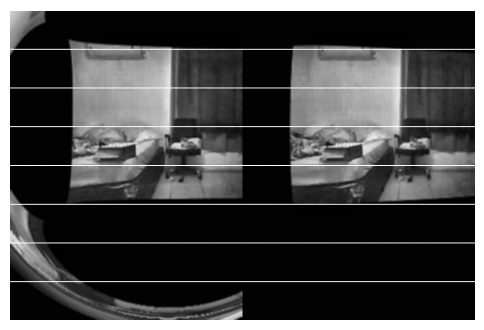

In [8]:
# ==============================
# VISUALIZAÇÃO DA RETIFICAÇÃO
# ==============================

combined = np.hstack((rect_grayL, rect_grayR))

for i in range(0, combined.shape[0],40):
    cv2.line(combined,(0,i),(combined.shape[1],i),255,1)

show(combined,gray=True)

In [9]:
# ==============================
# DETECTAR FEATURES
# ==============================

features = cv2.goodFeaturesToTrack(
    rect_grayL,
    maxCorners=2000,
    qualityLevel=0.01,
    minDistance=7,
    blockSize=7
)

features = np.float32(features)

In [10]:

# ==============================
# CORRESPONDÊNCIA (OPTICAL FLOW)
# ==============================

ptsR, status, err = cv2.calcOpticalFlowPyrLK(
    rect_grayL,
    rect_grayR,
    features,
    None,
    winSize=(21,21),
    maxLevel=3
)

goodL = features[status==1]
goodR = ptsR[status==1]

In [11]:
# ==============================
# FILTRO EPIPOLAR
# ==============================

vertical_error = np.abs(goodL[:,1] - goodR[:,1])
mask = vertical_error < 2

goodL = goodL[mask]
goodR = goodR[mask]

In [12]:
# ==============================
# DISPARIDADE
# ==============================

disparity = goodL[:,0] - goodR[:,0]

valid = disparity > 0

goodL = goodL[valid]
goodR = goodR[valid]
disparity = disparity[valid]

print("Total pontos:", len(disparity))

Total pontos: 69


In [13]:

# ==============================
# CALCULAR PROFUNDIDADE
# ==============================

focal = Q[2,3]
baseline = -1.0 / Q[3,2]

depth = (focal * baseline) / disparity

/tmp/ipykernel_15979/3818781269.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  color = int(depth_norm[i])


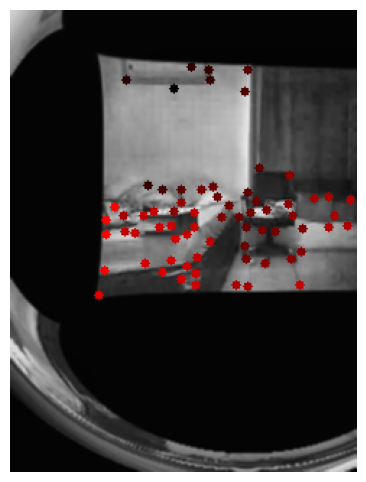

In [14]:
# ==============================
# VISUALIZAÇÃO SPARSE DEPTH
# ==============================

depth_vis = cv2.cvtColor(rect_grayL, cv2.COLOR_GRAY2BGR)

depth_norm = cv2.normalize(depth,None,0,255,cv2.NORM_MINMAX)

for i,(x,y) in enumerate(goodL.astype(int)):

    color = int(depth_norm[i])

    cv2.circle(depth_vis,(x,y),3,(0,0,color),-1)

show(depth_vis)

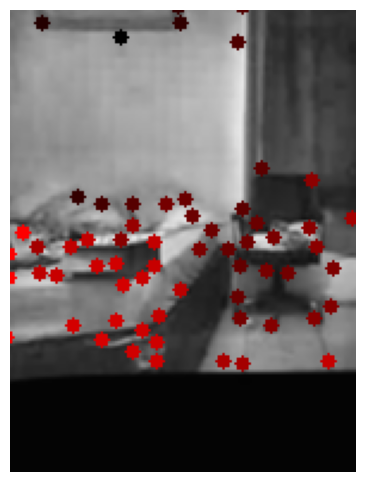

In [15]:
# ==============================
# APLICAR ROI
# ==============================

x,y,w,h = common_roi

depth_roi = depth_vis[y:y+h,x:x+w]

show(depth_roi)